# UNIQUE input data preparation: PPB

---

The process of preparing PPB input datasets to run UNIQUE Pipeline includes the following steps:
- Importing the preprocessed PPB dataset.
- Integrating predictions from Chemprop and corresponding uncertainty estimates (ensemble variance).
- Adding and scaling GNN latent fingerprints.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

## Load PPB data

In [2]:
df = pd.read_csv('data/PPB_dataset_with_splits.csv', index_col=0)
df.head()

,Id,Structure,mol,LogFu-Rat,LogFu-Human,Subset,split
0,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,<rdkit.Chem.rdchem.Mol object at 0x7744711fb6f0>,-1.731656,-1.900319,Training,train
1,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,<rdkit.Chem.rdchem.Mol object at 0x7744711fb990>,-0.907736,-0.984389,Training,train
2,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,<rdkit.Chem.rdchem.Mol object at 0x7744711fba00>,-2.639533,-1.836143,Training,train
3,Mol7,CC(C)NCC(O)COc1cccc2ccccc12,<rdkit.Chem.rdchem.Mol object at 0x7744711fba70>,-0.652241,NaN,Training,train
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,<rdkit.Chem.rdchem.Mol object at 0x7744711fbbc0>,-2.504456,-3.384078,Training,train


In [3]:
df['which_set'] = df['Subset'].copy()
df['which_set'] = df['which_set'].replace({'Training':'TRAIN', 'Calibration':'CALIBRATION', 'Validation':'TEST'})
df['which_set'].value_counts()

which_set
TRAIN          104
CALIBRATION     61
TEST            41
Name: count, dtype: int64

Select columns

In [4]:
df = df[['Id','Structure','LogFu-Rat','LogFu-Human','which_set']]
df.head()

,Id,Structure,LogFu-Rat,LogFu-Human,which_set
0,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,-1.731656,-1.900319,TRAIN
1,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,-0.907736,-0.984389,TRAIN
2,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,-2.639533,-1.836143,TRAIN
3,Mol7,CC(C)NCC(O)COc1cccc2ccccc12,-0.652241,NaN,TRAIN
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,-2.504456,-3.384078,TRAIN


## Read model predictions

In [5]:
df_preds = pd.read_csv('PPB_model/predictions.csv')
df_preds.head()

,Unnamed: 0,Id,Structure,mol,LogFu-Rat,LogFu-Human,Subset,split,LogFu-Rat_unc,LogFu-Human_unc
0,0,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,<rdkit.Chem.rdchem.Mol object at 0x7744711fb6f0>,-1.330273,-1.342664,Training,train,0.001371,0.002006
1,1,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,<rdkit.Chem.rdchem.Mol object at 0x7744711fb990>,-1.298461,-1.312423,Training,train,0.000714,0.000869
2,2,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,<rdkit.Chem.rdchem.Mol object at 0x7744711fba00>,-1.273289,-1.269884,Training,train,0.000543,0.000389
3,3,Mol7,CC(C)NCC(O)COc1cccc2ccccc12,<rdkit.Chem.rdchem.Mol object at 0x7744711fba70>,-1.184430,-1.234340,Training,train,0.000257,0.000378
4,4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,<rdkit.Chem.rdchem.Mol object at 0x7744711fbbc0>,-1.544915,-1.508519,Training,train,0.008277,0.008804


In [6]:
all([df.Id.iloc[x] == df_preds.Id.iloc[x] for x in range(df.shape[0])])

True

Rename columns

In [7]:
df_preds = df_preds.rename(columns={"LogFu-Rat": "predicted LogFu-Rat", "LogFu-Rat_unc": "variance LogFu-Rat",
                                    "LogFu-Human": "predicted LogFu-Human", "LogFu-Human_unc": "variance LogFu-Human"})

Select columns

In [8]:
df_preds = df_preds[['Id','predicted LogFu-Rat', 'predicted LogFu-Human','variance LogFu-Rat','variance LogFu-Human']]
df_preds.head()

,Id,predicted LogFu-Rat,predicted LogFu-Human,variance LogFu-Rat,variance LogFu-Human
0,Mol2,-1.330273,-1.342664,0.001371,0.002006
1,Mol5,-1.298461,-1.312423,0.000714,0.000869
2,Mol6,-1.273289,-1.269884,0.000543,0.000389
3,Mol7,-1.184430,-1.234340,0.000257,0.000378
4,Mol10,-1.544915,-1.508519,0.008277,0.008804


Merge predictions data

In [9]:
print(df.shape)
print(df_preds.shape)
df = df.merge(df_preds, on=['Id'])
print(df.shape)
df.head()

(206, 5)
(206, 5)
(206, 9)


,Id,Structure,LogFu-Rat,LogFu-Human,which_set,predicted LogFu-Rat,predicted LogFu-Human,variance LogFu-Rat,variance LogFu-Human
0,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,-1.731656,-1.900319,TRAIN,-1.330273,-1.342664,0.001371,0.002006
1,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,-0.907736,-0.984389,TRAIN,-1.298461,-1.312423,0.000714,0.000869
2,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,-2.639533,-1.836143,TRAIN,-1.273289,-1.269884,0.000543,0.000389
3,Mol7,CC(C)NCC(O)COc1cccc2ccccc12,-0.652241,NaN,TRAIN,-1.184430,-1.234340,0.000257,0.000378
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,-2.504456,-3.384078,TRAIN,-1.544915,-1.508519,0.008277,0.008804


## Read GNN latent representations

In [10]:
df_latent = pd.read_csv('PPB_model/latent_fps_0.csv')
df_latent.head()

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299
0,0.010701,0.0,0.077975,0.136766,0.127314,0.036145,0.072464,0.132873,0.0,0.0,0.0,0.000021,0.235046,0.073876,0.048372,0.081703,0.269276,0.0,0.356278,0.0,0.161763,0.057126,0.108893,0.173518,0.064004,0.229391,0.109181,0.047202,0.0,0.0,0.085796,0.0,0.016179,0.256325,0.099970,0.0,0.0,0.129044,0.0,0.209160,0.082762,0.001349,0.001011,0.034635,0.0,0.168846,0.194705,0.141833,0.019468,0.028782,0.050978,0.252720,0.0,0.064796,0.000000,0.265873,0.331899,0.0,0.036329,0.0,0.136826,0.120839,0.095990,0.000399,0.0,0.000000,0.000000,0.054348,0.040007,0.084970,0.223792,0.000318,0.281385,0.137064,0.032449,0.002823,0.028286,0.062494,0.022252,0.104682,0.0,0.017980,0.039651,0.038599,0.0,0.0,0.020823,0.101924,0.048165,0.026132,0.000480,0.075223,0.048350,0.014609,0.0,0.053976,0.012061,0.0,0.141798,0.084100,0.212696,0.196291,0.011241,0.072846,0.0,0.223910,0.0,0.186162,0.0,0.003812,0.242472,0.269919,0.156222,0.006089,0.051669,0.025396,0.047246,0.076316,0.232758,0.191502,0.0,0.223173,0.0,0.0,0.0,0.0,0.297300,0.071064,0.214185,0.213321,0.062623,0.010099,0.334869,0.0,0.328290,0.006171,0.007451,0.303663,0.0,0.057482,0.215756,0.122909,0.110850,0.227617,0.053593,0.094611,0.0,0.0,0.0,0.078785,0.091667,0.158633,0.125657,0.155841,0.033612,0.202904,0.106978,0.207460,0.0,0.148379,0.0,0.0,0.0,0.0,0.007751,0.123585,0.068835,0.264413,0.031074,0.0,0.030186,0.044975,0.0,0.190409,0.178235,0.041802,0.167760,0.0,0.0,0.0,0.027942,0.002746,0.283374,0.055522,0.189405,0.233513,0.039293,0.266465,0.004999,0.017508,0.135823,0.037345,0.0,0.043896,0.0,0.023432,0.139657,0.146518,0.284926,0.166880,0.173193,0.033271,0.062192,0.238571,0.117312,0.165401,0.236942,0.014556,0.0,0.0,0.0,0.0,0.121602,0.161634,0.0,0.0,0.127313,0.018422,0.0,0.0,0.0,0.196140,0.0,0.0,0.0,0.0,0.069292,0.135722,0.0,0.048916,0.108165,0.428757,0.369888,0.166273,0.348669,0.145275,0.107513,0.164172,0.011327,0.072356,0.059578,0.0,0.259603,0.163548,0.042330,0.114229,0.0,0.0,0.152205,0.053407,0.008050,0.026847,0.260439,0.0,0.0,0.0,0.050985,0.0,0.364734,0.0,0.210982,0.1

Add SMILES data

In [11]:
original_data = pd.read_csv('data/PPB_dataset_with_splits.csv', index_col=0)
smiles = original_data['Structure']
smiles

0      CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1
1      CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...
2      CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...
3                            CC(C)NCC(O)COc1cccc2ccccc12
4      CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...
                             ...                        
201             CN(C(=O)c1cc(N2CCNC2=O)ccc1F)C1CCC(N)CC1
202              O=C(NC12CCCC1NCC2)c1ccc(-c2cn[nH]c2)cc1
203            O=C(Nc1ccc(CN2CCCCC2)cc1)c1ccnc2[nH]cnc12
204           CCc1c[nH]c2ncnc(N3CCC(CN4CCN(C)CC4)CC3)c12
205             CC1CC(N)CCN1C(=O)c1cc(N2CCNC2=O)c(F)cc1F
Name: Structure, Length: 206, dtype: object

In [12]:
print(df_latent.shape)
print(smiles.shape)
df_latent = pd.concat([smiles, df_latent], axis=1)
print(df_latent.shape)
df_latent.head()

(206, 300)
(206,)
(206, 301)


,Structure,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299
0,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,0.010701,0.0,0.077975,0.136766,0.127314,0.036145,0.072464,0.132873,0.0,0.0,0.0,0.000021,0.235046,0.073876,0.048372,0.081703,0.269276,0.0,0.356278,0.0,0.161763,0.057126,0.108893,0.173518,0.064004,0.229391,0.109181,0.047202,0.0,0.0,0.085796,0.0,0.016179,0.256325,0.099970,0.0,0.0,0.129044,0.0,0.209160,0.082762,0.001349,0.001011,0.034635,0.0,0.168846,0.194705,0.141833,0.019468,0.028782,0.050978,0.252720,0.0,0.064796,0.000000,0.265873,0.331899,0.0,0.036329,0.0,0.136826,0.120839,0.095990,0.000399,0.0,0.000000,0.000000,0.054348,0.040007,0.084970,0.223792,0.000318,0.281385,0.137064,0.032449,0.002823,0.028286,0.062494,0.022252,0.104682,0.0,0.017980,0.039651,0.038599,0.0,0.0,0.020823,0.101924,0.048165,0.026132,0.000480,0.075223,0.048350,0.014609,0.0,0.053976,0.012061,0.0,0.141798,0.084100,0.212696,0.196291,0.011241,0.072846,0.0,0.223910,0.0,0.186162,0.0,0.003812,0.242472,0.269919,0.156222,0.006089,0.051669,0.025396,0.047246,0.076316,0.232758,0.191502,0.0,0.223173,0.0,0.0,0.0,0.0,0.297300,0.071064,0.214185,0.213321,0.062623,0.010099,0.334869,0.0,0.328290,0.006171,0.007451,0.303663,0.0,0.057482,0.215756,0.122909,0.110850,0.227617,0.053593,0.094611,0.0,0.0,0.0,0.078785,0.091667,0.158633,0.125657,0.155841,0.033612,0.202904,0.106978,0.207460,0.0,0.148379,0.0,0.0,0.0,0.0,0.007751,0.123585,0.068835,0.264413,0.031074,0.0,0.030186,0.044975,0.0,0.190409,0.178235,0.041802,0.167760,0.0,0.0,0.0,0.027942,0.002746,0.283374,0.055522,0.189405,0.233513,0.039293,0.266465,0.004999,0.017508,0.135823,0.037345,0.0,0.043896,0.0,0.023432,0.139657,0.146518,0.284926,0.166880,0.173193,0.033271,0.062192,0.238571,0.117312,0.165401,0.236942,0.014556,0.0,0.0,0.0,0.0,0.121602,0.161634,0.0,0.0,0.127313,0.018422,0.0,0.0,0.0,0.196140,0.0,0.0,0.0,0.0,0.069292,0.135722,0.0,0.048916,0.108165,0.428757,0.369888,0.166273,0.348669,0.145275,0.107513,0.164172,0.011327,0.072356,0.059578,0.0,0.259603,0.163548,0.042330,0.114229,0.0,0.0,0.152205,0.053407,0.008050,0.026847

In [13]:
# Drop duplicated latent profiles
df_latent = df_latent.drop_duplicates()
df_latent.shape

(206, 301)

Inspect feature distributions and outlier identification

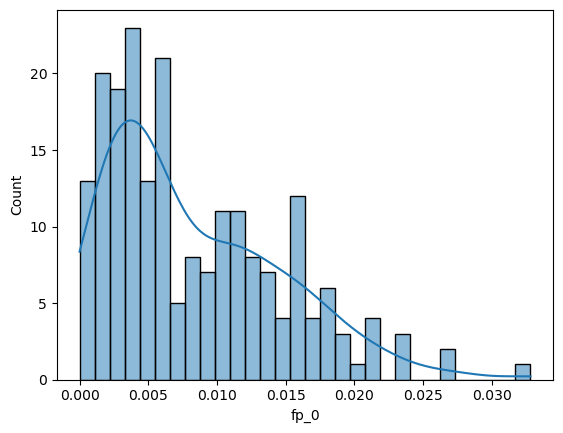

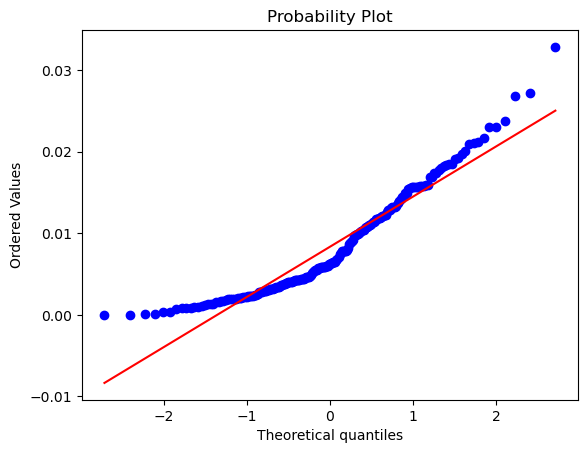

In [14]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# inspect the first latent feature
feature = df_latent['fp_0']
# histogram
sns.histplot(feature, kde=True, bins=30)
plt.show()
# Q-Q plot
stats.probplot(feature, dist="norm", plot=plt)
plt.show()

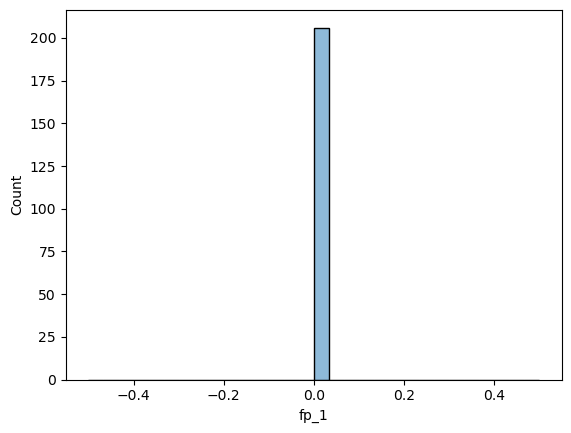

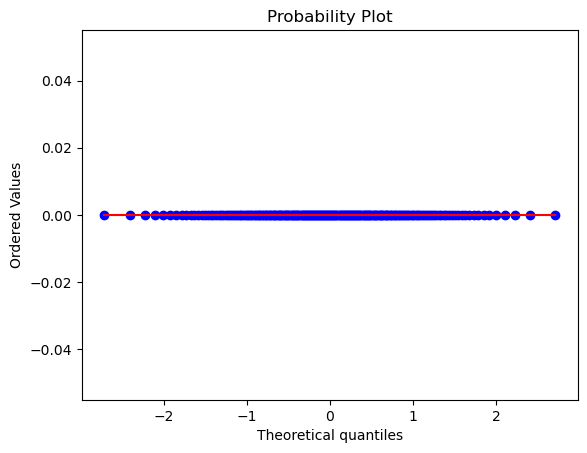

In [15]:
# inspect the second latent feature
feature = df_latent['fp_1']
# histogram
sns.histplot(feature, kde=True, bins=30)
plt.show()
# Q-Q plot
stats.probplot(feature, dist="norm", plot=plt)
plt.show()

In [16]:
print(df_latent['fp_0'].skew(axis=0, skipna=True))
print(df_latent['fp_1'].skew())

0.9540926209562277
0.0


In [17]:
def detect_outliers(df, feature):
    zscores = (df[feature] - df[feature].mean())/df[feature].std(ddof=0)

    lower_outliers = df[zscores < -3]
    upper_outliers = df[zscores > 3]

    lower_percent = len(lower_outliers) / len(df) * 100
    upper_percent = len(upper_outliers) / len(df) * 100

    return lower_percent, upper_percent

In [18]:
lower_percent, upper_percent = detect_outliers(df_latent, 'fp_0')
print(lower_percent, upper_percent)
lower_percent, upper_percent = detect_outliers(df_latent, 'fp_1')
print(lower_percent, upper_percent)

0.0 0.48543689320388345
0.0 0.0


Add latent fingerprint descriptors in a single column and scale them

In [19]:
df_latent['latent_fp'] = [np.array(df_latent.iloc[x, np.where(['fp_' in col for col in df_latent.columns])[0]]) for x in range(df_latent.shape[0])]
df_latent.head()

,Structure,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299,latent_fp
0,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,0.010701,0.0,0.077975,0.136766,0.127314,0.036145,0.072464,0.132873,0.0,0.0,0.0,0.000021,0.235046,0.073876,0.048372,0.081703,0.269276,0.0,0.356278,0.0,0.161763,0.057126,0.108893,0.173518,0.064004,0.229391,0.109181,0.047202,0.0,0.0,0.085796,0.0,0.016179,0.256325,0.099970,0.0,0.0,0.129044,0.0,0.209160,0.082762,0.001349,0.001011,0.034635,0.0,0.168846,0.194705,0.141833,0.019468,0.028782,0.050978,0.252720,0.0,0.064796,0.000000,0.265873,0.331899,0.0,0.036329,0.0,0.136826,0.120839,0.095990,0.000399,0.0,0.000000,0.000000,0.054348,0.040007,0.084970,0.223792,0.000318,0.281385,0.137064,0.032449,0.002823,0.028286,0.062494,0.022252,0.104682,0.0,0.017980,0.039651,0.038599,0.0,0.0,0.020823,0.101924,0.048165,0.026132,0.000480,0.075223,0.048350,0.014609,0.0,0.053976,0.012061,0.0,0.141798,0.084100,0.212696,0.196291,0.011241,0.072846,0.0,0.223910,0.0,0.186162,0.0,0.003812,0.242472,0.269919,0.156222,0.006089,0.051669,0.025396,0.047246,0.076316,0.232758,0.191502,0.0,0.223173,0.0,0.0,0.0,0.0,0.297300,0.071064,0.214185,0.213321,0.062623,0.010099,0.334869,0.0,0.328290,0.006171,0.007451,0.303663,0.0,0.057482,0.215756,0.122909,0.110850,0.227617,0.053593,0.094611,0.0,0.0,0.0,0.078785,0.091667,0.158633,0.125657,0.155841,0.033612,0.202904,0.106978,0.207460,0.0,0.148379,0.0,0.0,0.0,0.0,0.007751,0.123585,0.068835,0.264413,0.031074,0.0,0.030186,0.044975,0.0,0.190409,0.178235,0.041802,0.167760,0.0,0.0,0.0,0.027942,0.002746,0.283374,0.055522,0.189405,0.233513,0.039293,0.266465,0.004999,0.017508,0.135823,0.037345,0.0,0.043896,0.0,0.023432,0.139657,0.146518,0.284926,0.166880,0.173193,0.033271,0.062192,0.238571,0.117312,0.165401,0.236942,0.014556,0.0,0.0,0.0,0.0,0.121602,0.161634,0.0,0.0,0.127313,0.018422,0.0,0.0,0.0,0.196140,0.0,0.0,0.0,0.0,0.069292,0.135722,0.0,0.048916,0.108165,0.428757,0.369888,0.166273,0.348669,0.145275,0.107513,0.164172,0.011327,0.072356,0.059578,0.0,0.259603,0.163548,0.042330,0.114229,0.0,0.0,0.152205,0.053407,0.00805

Merge latent representations

In [20]:
set(df.Structure) == set(df_latent.Structure)

True

In [21]:
print(df.shape)
print(df_latent.shape)
df = df.merge(df_latent[['Structure','latent_fp']], on=['Structure'])
print(df.shape)
df.head()

(206, 9)
(206, 302)
(206, 10)


,Id,Structure,LogFu-Rat,LogFu-Human,which_set,predicted LogFu-Rat,predicted LogFu-Human,variance LogFu-Rat,variance LogFu-Human,latent_fp
0,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,-1.731656,-1.900319,TRAIN,-1.330273,-1.342664,0.001371,0.002006,"[0.010700971, 0.0, 0.07797528, 0.13676615, 0.1..."
1,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,-0.907736,-0.984389,TRAIN,-1.298461,-1.312423,0.000714,0.000869,"[0.005864944, 0.0, 0.06741323, 0.1634363, 0.11..."
2,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,-2.639533,-1.836143,TRAIN,-1.273289,-1.269884,0.000543,0.000389,"[0.013092317, 0.0, 0.054835793, 0.15550476, 0...."
3,Mol7,CC(C)NCC(O)COc1cccc2ccccc12,-0.652241,NaN,TRAIN,-1.184430,-1.234340,0.000257,0.000378,"[0.0036706561, 0.0, 0.048058886, 0.09438541, 0..."
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,-2.504456,-3.384078,TRAIN,-1.544915,-1.508519,0.008277,0.008804,"[0.021122517, 0.0, 0.14039071, 0.116333276, 0...."


Given that most of latent fingerprint features show a positively skewed distribution (which does not follow a Gaussian distribution) and have a significant percentage of outliers (more than 0.3% as determined from the Z-score detection method), we employed a Robust Scaler to perform feature transformation, rather than using a Standard Scaler.

In [22]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaler.fit(np.array([np.array(x) for x in df[df.which_set == 'TRAIN'].latent_fp]))
df['latent_fp_scaled'] = [list(i) for i in scaler.transform(np.array([np.array(x) for x in df.latent_fp]))]
df = df.drop(columns='latent_fp')
df.head()

,Id,Structure,LogFu-Rat,LogFu-Human,which_set,predicted LogFu-Rat,predicted LogFu-Human,variance LogFu-Rat,variance LogFu-Human,latent_fp_scaled
0,Mol2,CCOc1cc2nn(CCC(C)(C)O)cc2cc1NC(=O)c1cccc(C(F)F)n1,-1.731656,-1.900319,TRAIN,-1.330273,-1.342664,0.001371,0.002006,"[0.4156077261860907, 0.0, 0.303830083190755, -..."
1,Mol5,CC(C)(O)CCn1cc2cc(NC(=O)c3cccc(C(F)(F)F)n3)c(C...,-0.907736,-0.984389,TRAIN,-1.298461,-1.312423,0.000714,0.000869,"[-0.06622093728985884, 0.0, 0.1026555644076115..."
2,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,-2.639533,-1.836143,TRAIN,-1.273289,-1.269884,0.000543,0.000389,"[0.6538650905656853, 0.0, -0.13690586883691086..."
3,Mol7,CC(C)NCC(O)COc1cccc2ccccc12,-0.652241,NaN,TRAIN,-1.184430,-1.234340,0.000257,0.000378,"[-0.28484477998934093, 0.0, -0.265985072643285..."
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,-2.504456,-3.384078,TRAIN,-1.544915,-1.508519,0.008277,0.008804,"[1.453939311293686, 0.0, 1.4926517697850235, -..."


## Save final datasets

Save the generated UNIQUE input dataset for each endpoint into a separate CSV file.

In [23]:
for endpoint in ['LogFu-Rat', 'LogFu-Human']:

    print(f'\n{endpoint}')
    df_endpoint = df[['Id', 'Structure', f'{endpoint}', f'predicted {endpoint}', f'variance {endpoint}', 'which_set', 'latent_fp_scaled']]
    df_endpoint.columns = ['Id', 'Structure', 'labels', 'predictions', 'variance', 'which_set', 'latent_fp_scaled']

    print(df_endpoint.shape)
    df_endpoint = df_endpoint.dropna()
    print(df_endpoint.shape)

    print(df_endpoint.which_set.value_counts())
    print(df_endpoint.which_set.value_counts()/df_endpoint.which_set.value_counts().sum() * 100)

    df_endpoint.to_csv(f'unique_input_data/{endpoint}_unique_input_data.csv')


LogFu-Rat
(206, 7)
(167, 7)
which_set
TRAIN          87
CALIBRATION    48
TEST           32
Name: count, dtype: int64
which_set
TRAIN          52.095808
CALIBRATION    28.742515
TEST           19.161677
Name: count, dtype: float64

LogFu-Human
(206, 7)
(193, 7)
which_set
TRAIN          96
CALIBRATION    58
TEST           39
Name: count, dtype: int64
which_set
TRAIN          49.740933
CALIBRATION    30.051813
TEST           20.207254
Name: count, dtype: float64
